# import libraries

In [1]:
import os
import time
from pathlib import Path

import pandas as pd  
import time 
from tqdm import tqdm 
from dotenv import load_dotenv, find_dotenv


# Directories

In [2]:
DATA_DIR = Path("../data")
LATEST_MOVIES_PATH = DATA_DIR / 'latest_movies' / "latest_movies_fully_translated.csv"
TMDB_DIR = DATA_DIR / 'tmdb'
MOVIELENS_DIR = DATA_DIR / 'movielens'
print(f"DATA_DIR: {DATA_DIR.resolve()}")


DATA_DIR: C:\52300070_TMTHUYEN\LEARN_MORE\Apps\dacntt-movie-recommendation\ai-service\data


# Các hàm util thống kê và vẽ biểu đồ

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_count_by_range(
    df_has_overview_vi,  # nhận vào df chưa overview_vi, từ đếm từ
    bins=None,
    title="Phân phối số từ theo khoảng",
    x_label="Khoảng số từ",
    y_label="Số lượng phim",
    figsize=(10, 6),
):
    if bins is None:
        bins = [0, 10, 20, 30, 50, 100, float("inf")]
    df_has_overview_vi['overview_vi_word_count'] = df_has_overview_vi['overview_vi'].fillna("").str.split().str.len()

    series = df_has_overview_vi['overview_vi_word_count']
    values = pd.to_numeric(series, errors="coerce").dropna()

    ranges = pd.cut(
        values,
        bins=bins,
        include_lowest=True,
        right=False,
    )

    distribution = ranges.value_counts().sort_index()

    ax = distribution.plot(
        kind="bar",
        figsize=figsize,
        color="steelblue",
        edgecolor="black",
    )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.tick_params(axis="x", rotation=45)

    for index, value in enumerate(distribution):
        ax.text(
            index,
            value,
            str(value),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    return distribution


# Load data

## MovieLens dataset

In [4]:
movielens_df = {
    "ratings": pd.read_csv(MOVIELENS_DIR / "ratings.csv"),
    "tags": pd.read_csv(MOVIELENS_DIR / "tags.csv"),
    "links": pd.read_csv(MOVIELENS_DIR / "links.csv"),
    "movies": pd.read_csv(MOVIELENS_DIR / "movies.csv"),
    "genome_scores": pd.read_csv(MOVIELENS_DIR / "genome_scores.csv"),
    "genome_tags": pd.read_csv(MOVIELENS_DIR / "genome_tags.csv")
}

print('Số phim: ', movielens_df['movies'].shape[0]) 
print('Số người dùng: ', movielens_df['ratings']['userId'].nunique())
print('Số lượt đánh giá: ', movielens_df['ratings'].shape[0])


Số phim:  58098
Số người dùng:  283228
Số lượt đánh giá:  27753444


In [5]:

display(movielens_df['movies'].head(5))
display(movielens_df['ratings'].head(5))
# display(movielens_df['tags'].head(5))
display(movielens_df['links'].head(5))
# display(movielens_df['genome_scores'].head(5))
# display(movielens_df['genome_tags'].head(5))

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,307,3.5,1256677221
1,1,481,3.5,1256677456
2,1,1091,1.5,1256677471
3,1,1257,4.5,1256677460
4,1,1449,4.5,1256677264


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


## TMDB movies info

Thông tin cơ bản về data:


tmdbId                   14815
title_vi                 14815
overview_vi              14815
genres                   14815
release_date             14815
poster_path              14795
adult                    14815
backdrop_path            14403
belongs_to_collection     2262
budget                   14815
homepage                     1
id                       14815
imdb_id                  14812
origin_country           14815
original_language        14815
original_title           14815
overview                 14815
popularity               14815
production_companies     14815
production_countries     14815
revenue                  14815
runtime                  14815
softcore                 14815
spoken_languages         14815
status                   14815
tagline                    643
title                    14815
video                    14815
vote_average             14815
vote_count               14815
movieId                  14815
is_ai_translated         14815
dtype: i

<class 'pandas.DataFrame'>
Index: 14815 entries, 0 to 14823
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tmdbId                 14815 non-null  float64
 1   title_vi               14815 non-null  str    
 2   overview_vi            14815 non-null  str    
 3   genres                 14815 non-null  str    
 4   release_date           14815 non-null  str    
 5   poster_path            14795 non-null  str    
 6   adult                  14815 non-null  bool   
 7   backdrop_path          14403 non-null  str    
 8   belongs_to_collection  2262 non-null   str    
 9   budget                 14815 non-null  int64  
 10  homepage               1 non-null      str    
 11  id                     14815 non-null  int64  
 12  imdb_id                14812 non-null  str    
 13  origin_country         14815 non-null  str    
 14  original_language      14815 non-null  str    
 15  original_title    

None

,tmdbId,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,softcore,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated
0,131232.0,Due amici,"Bạn bè hai tuổi, Nunzio và Pino, có chung một ...","[{'id': 18, 'name': 'Phim Chính Kịch'}]",2002-03-20,/ja7a0XvTUIQ6w1YdvbtytdC1lTF.jpg,False,/r1boovecPQAZo6vQBLZ4NVeRT2g.jpg,NaN,0,...,False,"[{'english_name': 'Italian', 'iso_639_1': 'it'...",Released,NaN,Due amici,False,5.400,7,723.0,True
1,79782.0,Wenecja,Một câu chuyện sắp tới kể về một cậu bé tên là...,"[{'id': 18, 'name': 'Phim Chính Kịch'}, {'id':...",2010-06-11,/jk8PwaZ14Duxy8hmLbYLFcYTUP9.jpg,False,/8vrmhLhPucmEOJr6EDxhxzVDMXi.jpg,NaN,1783810,...,False,"[{'english_name': 'Czech', 'iso_639_1': 'cs', ...",Released,NaN,Wenecja,False,7.139,18,895.0,True
2,141210.0,The Sleepover,"Thị trấn Derry có một bí mật, nhưng không ai n...","[{'id': 35, 'name': 'Phim Hài'}, {'id': 27, 'n...",2012-10-12,/tdaZD1Db9CXu96oLdAHElJsBPfb.jpg,False,NaN,NaN,0,...,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,The Sleepover,False,6.500,11,1115.0,True
3,143750.0,The Farmer's Wife,Khi môi trường của cô bị xâm chiếm bởi người n...,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2012-06-20,NaN,False,NaN,NaN,0,...,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,The Farmer's Wife,False,10.000,1,2223.0,True
4,84198.0,A Place at the Table,"Sử dụng những câu chuyện cá nhân, những tài li...","[{'id': 99, 'name': 'Phim Tài Liệu'}]",2012-03-22,/ptli8HtDrapZdVdBnYSN8zxJtw0.jpg,False,/hdFefzO4RPq4txKEbFU7EulePsS.jpg,NaN,0,...,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,A Place at the Table,False,6.593,27,2679.0,True


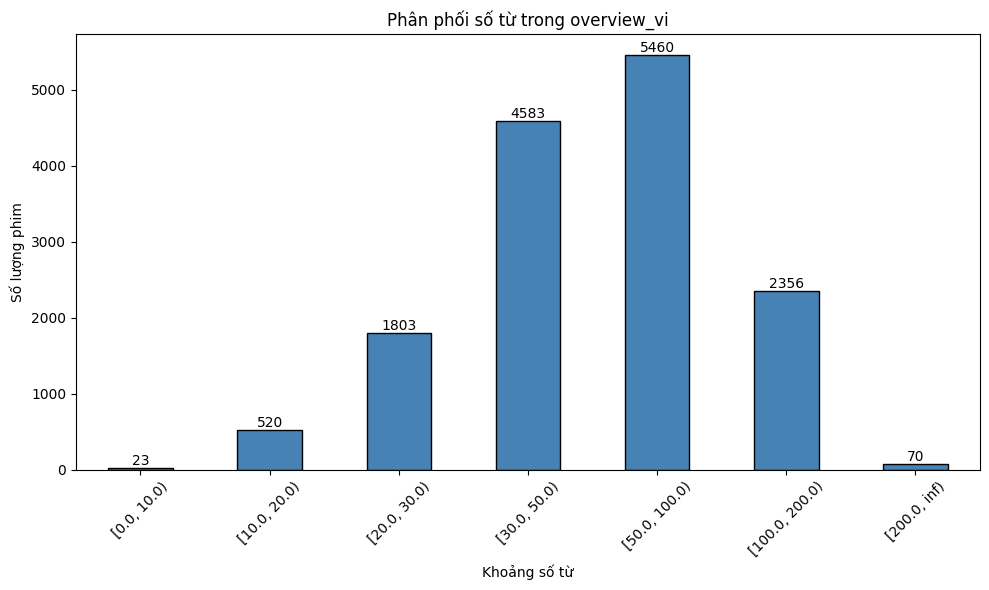

,tmdbId,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
8505,15261.0,Bring It On: In It to Win It,,"[{'id': 35, 'name': 'Phim Hài'}]",2007-10-29,/hMRjQuTZQ8bZNrwqkKhBgbh8MkF.jpg,False,/o5vEn254g1FAYNfCTVrhodIj1SM.jpg,"{'id': 430186, 'name': 'Bring It On Collection...",0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Bring It On: In It to Win It,False,6.400,549,118512.0,True,0
10422,282919.0,Diebinnen,,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",1996-06-20,NaN,False,NaN,NaN,0,...,[],Released,NaN,Diebinnen,False,6.000,2,826.0,True,0
10791,9427.0,The Full Monty,"Sheffield, Anh Quốc.","[{'id': 35, 'name': 'Phim Hài'}]",1997-08-13,/fjg4EvzoLZVcZli4BwJIytJ6yjn.jpg,False,/r8SwFiCeaADf0jIotMMtfNBzLEI.jpg,NaN,3500000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,The Full Monty,False,7.002,1851,1641.0,True,3
4422,106537.0,Michael Jackson: Life of a Superstar,Câu chuyện của Vua Đại,"[{'id': 99, 'name': 'Phim Tài Liệu'}, {'id': 1...",2008-12-31,NaN,False,NaN,NaN,0,...,[],Released,NaN,Michael Jackson: Life of a Superstar,False,10.000,1,72321.0,True,5
8787,53214.0,Signs,Anh tìm thấy tình yêu ở đâu?,"[{'id': 10749, 'name': 'Phim Lãng Mạn'}]",2008-03-10,/AbYvRIrytssdAwkjn8B6778qguT.jpg,False,/vgjmOUIyBFvTXnuDqj1QF5BKLnO.jpg,NaN,0,...,[],Released,NaN,Signs,False,7.217,122,126008.0,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,8849.0,Alfie,Một câu chuyện về một người phụ nữ triết học n...,"[{'id': 35, 'name': 'Phim Hài'}, {'id': 18, 'n...",2004-10-22,/dvKvkoc2d06cOSheq5hQ7G4FJJX.jpg,False,/fTs7kWfwaYpM8OuzMMoimsMSTUI.jpg,NaN,60000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Alfie,False,5.857,901,8948.0,True,24
10661,28059.0,SubUrbia,Một nhóm trẻ vị thành niên cố gắng hỗ trợ lẫn ...,"[{'id': 35, 'name': 'Phim Hài'}, {'id': 18, 'n...",1997-02-07,/7PdRbG09K9JHYyOwwCSn3OdJb0N.jpg,False,/m3lFal27s4wY96nrP3t2k0rbRzY.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,SubUrbia,False,6.208,142,1454.0,True,22
10192,21450.0,Naked,Một tên người Anh vô dụng trút cơn thịnh nộ lê...,"[{'id': 18, 'name': 'Phim Chính Kịch'}, {'id':...",1993-08-06,/xMYP4uaNeyPmX4FQ2xxWk2eIN6K.jpg,False,/uIh3mW3AuSM7ww7NYtvSWDQ1zc7.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Naked,False,7.300,695,501.0,True,23
3411,16666.0,War Dance,Ba đứa trẻ sống trong một trại cắm trại ở miền...,"[{'id': 99, 'name': 'Phim Tài Liệu'}, {'id': 1...",2007-02-15,/mZxKlZSaL0VvBfmiZX3dv3BKVH5.jpg,False,/dOsFxHgM5dJiTeVMei2KSQMOYF9.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,War Dance,False,7.158,19,58309.0,True,23


tmdbId                    23
title_vi                  23
overview_vi               23
genres                    23
release_date              23
poster_path               21
adult                     23
backdrop_path             18
belongs_to_collection      5
budget                    23
homepage                   0
id                        23
imdb_id                   23
origin_country            23
original_language         23
original_title            23
overview                  23
popularity                23
production_companies      23
production_countries      23
revenue                   23
runtime                   23
softcore                  23
spoken_languages          23
status                    23
tagline                    0
title                     23
video                     23
vote_average              23
vote_count                23
movieId                   23
is_ai_translated          23
overview_vi_word_count    23
dtype: int64

In [6]:
# tmdb_df1 = pd.read_csv(TMDB_DIR / 'movies_metadata_0-10000_1995-01-01.csv')
# tmdb_df2 = pd.read_csv(TMDB_DIR / 'movies_metadata_11000-20000_1995-01-01.csv')

# # merge
# tmdb_df = pd.concat([tmdb_df1, tmdb_df2], ignore_index=True)
# tmdb_df.to_csv(TMDB_DIR / 'movies_metadata_merged.csv', index=False, encoding='utf-8-sig')

# tmdb_df = pd.read_csv(TMDB_DIR / 'movies_metadata_merged_2000-01-01.csv', encoding='utf-8-sig')
# # tmdb_df2 = pd.read_csv(TMDB_DIR / 'movies_vietnamese_metadata_min-10-rating_1990_fully_translated.csv', encoding='utf-8-sig')
# tmdb_df = pd.concat([tmdb_df, tmdb_df2], ignore_index=True)
# tmdb_df.to_csv(TMDB_DIR / 'movies_data_fully_translated.csv', index=False, encoding='utf-8-sig')

# Đọc data 
tmdb_df = pd.read_csv(TMDB_DIR / 'movies_data_fully_translated.csv', encoding='utf-8-sig')

# Loại trùng
tmdb_df = tmdb_df.drop_duplicates(subset=['id'], keep='first')

# Fill NaN cho overview_vi và overview
tmdb_df['overview_vi'] = tmdb_df['overview_vi'].fillna('')
tmdb_df['overview'] = tmdb_df['overview'].fillna('')
# Nếu overview trống thì gán overview_vi = overview
tmdb_df.loc[tmdb_df['overview'].str.strip() == '', 'overview_vi'] = tmdb_df['overview']


# Thông tin cơ bản về data
print("Thông tin cơ bản về data:")
display(tmdb_df.count())
display(tmdb_df.info())
display(tmdb_df.head(5))

# Phân phối số từ của overview_vi
word_count_distribution = plot_count_by_range(
    tmdb_df,
    bins=[0, 10, 20, 30, 50, 100, 200, float("inf")],
    title="Phân phối số từ trong overview_vi",
)

# hiển thị head theo số từ
display(tmdb_df.sort_values('overview_vi', key=lambda x: x.str.len()).head(1000))

# Loại những dòng có overview trống hoặc overview_vi < 10 từ
short_movies_df = tmdb_df[(tmdb_df['overview_vi'].str.split().str.len() < 10) | (tmdb_df['overview'].str.strip() == '')] # overview = ''
display(short_movies_df.count())

## Latest TMDB movies 

<class 'pandas.DataFrame'>
RangeIndex: 5074 entries, 0 to 5073
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tmdbId                 5074 non-null   int64  
 1   title_vi               5074 non-null   str    
 2   overview_vi            5074 non-null   str    
 3   genres                 5074 non-null   str    
 4   release_date           5068 non-null   str    
 5   poster_path            4333 non-null   str    
 6   adult                  5074 non-null   bool   
 7   backdrop_path          2788 non-null   str    
 8   belongs_to_collection  132 non-null    str    
 9   budget                 5074 non-null   int64  
 10  homepage               9 non-null      str    
 11  id                     5074 non-null   int64  
 12  imdb_id                2212 non-null   str    
 13  origin_country         5074 non-null   str    
 14  original_language      5074 non-null   str    
 15  original_title 

None

tmdbId                   5074
title_vi                 5074
overview_vi              5074
genres                   5074
release_date             5068
poster_path              4333
adult                    5074
backdrop_path            2788
belongs_to_collection     132
budget                   5074
homepage                    9
id                       5074
imdb_id                  2212
origin_country           5074
original_language        5074
original_title           5074
overview                 4360
popularity               5074
production_companies     5074
production_countries     5074
revenue                  5074
runtime                  5074
softcore                 5074
spoken_languages         5074
status                   5074
tagline                    45
title                    5074
video                    5074
vote_average             5074
vote_count               5074
movieId                     0
is_ai_translated         5074
dtype: int64

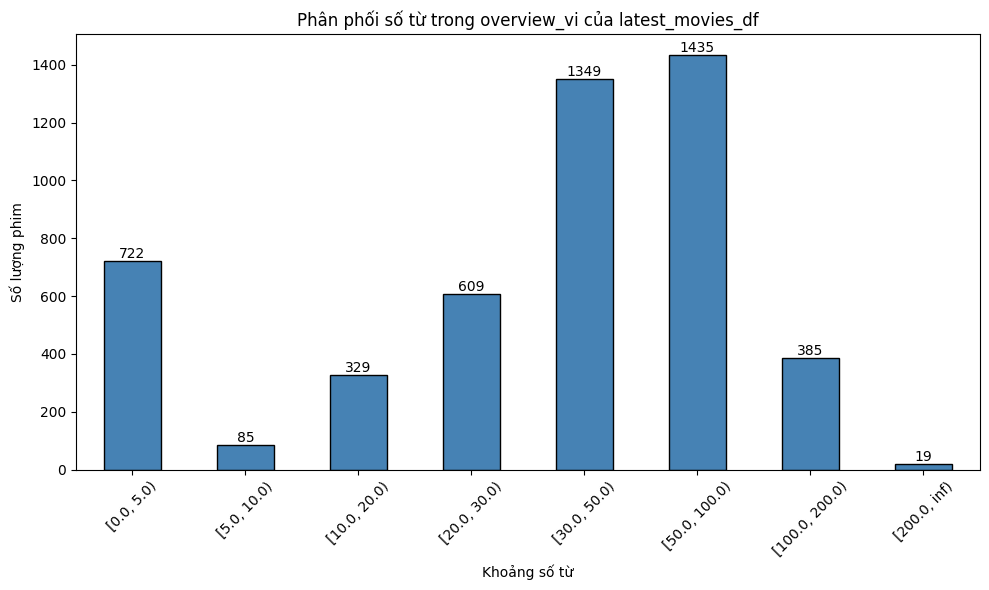

,tmdbId,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
5061,1768958,Une petite école française,,"[{'id': 99, 'name': 'Phim Tài Liệu'}]",2026-08-31,/mVQFgiFDMwMCdMomDbQQMG2Q4JA.jpg,False,/eXsci8PVrKmTXgudiPxK9O5kjG.jpg,NaN,0,...,[],Released,NaN,Une petite école française,False,0.0,0,NaN,True,0
4728,1745676,먼지,,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2026-08-22,NaN,False,NaN,NaN,0,...,[],Released,NaN,먼지,False,0.0,0,NaN,True,0
1060,1751967,Máscara contra Cabellera,,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2026-08-26,/ia2dMAJ9Yn6iyskKKpTYP7oOcRu.jpg,False,/aBtWFvaw3gTDeiy6KIQhp2kkci5.jpg,NaN,5300,...,"[{'english_name': 'Spanish', 'iso_639_1': 'es'...",Released,NaN,Máscara contra Cabellera,False,0.0,0,NaN,True,0
984,1759436,Šmik!,,"[{'id': 16, 'name': 'Phim Hoạt Hình'}]",2026-09-03,NaN,False,NaN,NaN,0,...,[],Released,NaN,Šmik!,False,0.0,0,NaN,True,0
983,1584452,Psoty,,"[{'id': 10751, 'name': 'Phim Gia Đình'}, {'id'...",2026-01-16,/fddlkJGlz3W9QE1s5BcFUbPKbns.jpg,False,/pc4wuqhvjdKSno3OAx8rAYgknnn.jpg,NaN,0,...,"[{'english_name': 'Polish', 'iso_639_1': 'pl',...",Released,NaN,Psoty,False,8.5,2,NaN,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3926,1747951,Crimes and Mis-Gnome-Meanors,Một người nhận được một tiếng gọi có thể bí mậ...,"[{'id': 80, 'name': 'Phim Hình Sự'}, {'id': 53...",2026-08-17,/yuQLohwHKBS0ffUQUuRsGrltzzc.jpg,False,/5NZ9kNRmWHkC2pRpQB8jYLxMl0S.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Crimes and Mis-Gnome-Meanors,False,8.0,1,NaN,True,16
274,1754427,Settlement,"Trong khi thiên nhiên, bốn người bạn gặp phải ...","[{'id': 27, 'name': 'Phim Kinh Dị'}]",2026-08-21,/91hu6GV03xcSV3qfU5qulIHDXNv.jpg,False,NaN,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Settlement,False,0.0,0,NaN,True,15
3764,1743302,Missing delivery,♪ Một cậu bé đang tìm kiếm người anh em mất tí...,"[{'id': 9648, 'name': 'Phim Bí Ẩn'}, {'id': 53...",2026-08-06,/qT9FdnkOKmwGlQYBnrVA3coj1lb.jpg,False,/9nVSGT8E1z1oRsf1A8865qwS3Lg.jpg,NaN,0,...,[],Released,NaN,Missing delivery,False,0.0,0,NaN,True,17
2812,1745219,Плохой сон,"Nhưng vì lý do nào đó, Vitya cảm thấy như cơn ...","[{'id': 27, 'name': 'Phim Kinh Dị'}]",2026-08-20,/lFGkYr9h5bdLfzl895fSyUy7kQH.jpg,False,NaN,NaN,0,...,"[{'english_name': 'Russian', 'iso_639_1': 'ru'...",Released,NaN,Плохой сон,False,0.0,0,NaN,True,17


,tmdbId,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
880,75571,デジモンアドベンチャー ぼくらのウォーゲーム!,Mùa xuân biến thành cuộc chiến mùa hè khi lũ q...,"[{'id': 12, 'name': 'Phim Phiêu Lưu'}, {'id': ...",2000-03-04,/dNCPzcUc5XTJeeX0TBuLgO9ZlNh.jpg,False,/m3g7v9ChQE2keBS4RMUxfmWn1xy.jpg,"{'id': 1214258, 'name': 'デジモンアドベンチャー（短編映画）シリーズ...",0,...,"[{'english_name': 'Japanese', 'iso_639_1': 'ja...",Released,NaN,デジモンアドベンチャー ぼくらのウォーゲーム!,False,8.000,74,NaN,True,55
1638,85265,Anak,"Sau khi làm việc ở nước ngoài, một phụ nữ đến ...","[{'id': 18, 'name': 'Phim Chính Kịch'}]",2000-05-10,/vz1Lntn8qnQon0lbO3hlSfN0hJJ.jpg,False,/g7rNNUQJsDM1tvoPWEdnvjKQK1N.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Anak,False,6.600,11,NaN,True,26
1298,230562,Tanging Yaman,"Ba anh em Danny, Art và Grace bây giờ đã ổn đị...","[{'id': 10751, 'name': 'Phim Gia Đình'}, {'id'...",2000-11-08,/3UbZUv7qhjsSjkoIZMMuZHC3YgK.jpg,False,/5yG6qiupfMzaCuRWWiIEwSUxxGs.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Tanging Yaman,False,7.000,3,NaN,True,110
120,1734,Xác Ướp 2: Trở Lại,Đã 8 năm trôi qua kể từ khi Rick và Evelyn lần...,"[{'id': 12, 'name': 'Phim Phiêu Lưu'}, {'id': ...",2001-05-04,/f9mqQwQzGXbmztktVoVO27X7M4a.jpg,False,/7s7WkAFPBsMTprYMbqbgKoppQsR.jpg,"{'id': 1733, 'name': 'Loạt phim Xác Ướp', 'pos...",98000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Xác Ướp 2: Trở Lại,False,6.416,7892,NaN,False,86
72,808,Shrek,Vương quốc Xa thật xa là nơi các nhân vật cổ t...,"[{'id': 16, 'name': 'Phim Hoạt Hình'}, {'id': ...",2001-05-18,/iB64vpL3dIObOtMZgX3RqdVdQDc.jpg,False,/w0eKUOEog2ImtktCHAMUZws8qif.jpg,"{'id': 2150, 'name': 'Loạt phim Shrek', 'poste...",60000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Câu chuyện thần tiên vĩ đại nhất chưa từng đuợ...,Shrek,False,7.779,19290,NaN,False,107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083,1745959,HISTERISMO,Giữa những chuyến đi tàu điện ngầm và buổi chi...,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2026-08-08,/tXrDzGAfgfXGpBKJJV6sXNOcF0a.jpg,False,/2c0HTlJaZvkA8OGcYEDzgxIUWvz.jpg,NaN,0,...,"[{'english_name': 'Portuguese', 'iso_639_1': '...",Released,NaN,HISTERISMO,False,0.000,0,NaN,True,36
1131,1754363,PROXY,Nhưng giấc mơ trở thành một cơn ác mộng khi họ...,"[{'id': 878, 'name': 'Phim Khoa Học Viễn Tưởng...",2026-08-08,NaN,False,NaN,NaN,20,...,[],Released,NaN,PROXY,False,0.000,0,NaN,True,34
1143,1738718,Благоустройство,Một mùa hè nóng là trong mùa xuân đầy đủ. một ...,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2026-08-08,/qSMnava610zvZQJB2lut5waS6Ro.jpg,False,NaN,NaN,0,...,"[{'english_name': 'Russian', 'iso_639_1': 'ru'...",Released,NaN,Благоустройство,False,0.000,0,NaN,True,115
1160,1746200,reminiscência.,,"[{'id': 18, 'name': 'Phim Chính Kịch'}, {'id':...",2026-08-08,/czyOVsZ9nyrAi1PywYcmOn4Ntzj.jpg,False,/w4kQcbRmmZCpMMMLUCxHrX056AS.jpg,NaN,0,...,[],Released,NaN,reminiscência.,False,0.000,0,NaN,True,0


tmdbId                    807
title_vi                  807
overview_vi               807
genres                    807
release_date              802
poster_path               611
adult                     807
backdrop_path             345
belongs_to_collection       7
budget                    807
homepage                    0
id                        807
imdb_id                   116
origin_country            807
original_language         807
original_title            807
overview                  807
popularity                807
production_companies      807
production_countries      807
revenue                   807
runtime                   807
softcore                  807
spoken_languages          807
status                    807
tagline                     0
title                     807
video                     807
vote_average              807
vote_count                807
movieId                     0
is_ai_translated          807
overview_vi_word_count    807
dtype: int

In [7]:
latest_movies_df = pd.read_csv(LATEST_MOVIES_PATH)

display(latest_movies_df.info())

display(latest_movies_df.count())

# Loại trùng
latest_movies_df = latest_movies_df.drop_duplicates(subset=['id'], keep='first')

# fill NaN cho overview_vi và overview
latest_movies_df['overview_vi'] = latest_movies_df['overview_vi'].fillna('')
latest_movies_df['overview'] = latest_movies_df['overview'].fillna('')
# Nếu overview trống thì gán overview_vi = overview
latest_movies_df.loc[latest_movies_df['overview'].str.strip() == '', 'overview_vi'] = latest_movies_df['overview']

# Vẽ phân phối số từ của overview_vi trong latest_movies_df
plot_count_by_range(
    latest_movies_df,
    bins=[0, 5, 10, 20, 30, 50, 100, 200, float("inf")],
    title="Phân phối số từ trong overview_vi của latest_movies_df",
)

# Hiện thị head: theo số từ trong overview_vi, từ ít đến nhiều
display(latest_movies_df.sort_values('overview_vi', key=lambda x: x.str.len()).head(1000))
display(latest_movies_df.sort_values('release_date', ascending=True).head(1000))


# Loại những dòng có overview trống hoặc overview_vi < 10 từ
short_movies_df = latest_movies_df[(latest_movies_df['overview_vi'].str.split().str.len() < 10) | (latest_movies_df['overview'].str.strip() == '')] # overview = ''
display(short_movies_df.count())

# Merge datasets: movielens (tmdb) + latest tmdb

Số phim không có movieId là latest_movies_df:  4891
Thông tin cơ bản về all_movies_df:


tmdbId                    19706
title_vi                  19706
overview_vi               19706
genres                    19706
release_date              19700
poster_path               18983
adult                     19706
backdrop_path             17093
belongs_to_collection      2371
budget                    19706
homepage                     10
id                        19706
imdb_id                   16951
origin_country            19706
original_language         19706
original_title            19706
overview                  19706
popularity                19706
production_companies      19706
production_countries      19706
revenue                   19706
runtime                   19706
softcore                  19706
spoken_languages          19706
status                    19706
tagline                     675
title                     19706
video                     19706
vote_average              19706
vote_count                19706
movieId                   14815
is_ai_tr

<class 'pandas.DataFrame'>
Index: 19706 entries, 0 to 19747
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tmdbId                  19706 non-null  float64
 1   title_vi                19706 non-null  str    
 2   overview_vi             19706 non-null  str    
 3   genres                  19706 non-null  str    
 4   release_date            19700 non-null  str    
 5   poster_path             18983 non-null  str    
 6   adult                   19706 non-null  bool   
 7   backdrop_path           17093 non-null  str    
 8   belongs_to_collection   2371 non-null   str    
 9   budget                  19706 non-null  int64  
 10  homepage                10 non-null     str    
 11  id                      19706 non-null  int64  
 12  imdb_id                 16951 non-null  str    
 13  origin_country          19706 non-null  str    
 14  original_language       19706 non-null  str    
 15  o

None

,tmdbId,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
0,131232.0,Due amici,"Bạn bè hai tuổi, Nunzio và Pino, có chung một ...","[{'id': 18, 'name': 'Phim Chính Kịch'}]",2002-03-20,/ja7a0XvTUIQ6w1YdvbtytdC1lTF.jpg,False,/r1boovecPQAZo6vQBLZ4NVeRT2g.jpg,NaN,0,...,"[{'english_name': 'Italian', 'iso_639_1': 'it'...",Released,NaN,Due amici,False,5.400,7,723.0,True,126
1,79782.0,Wenecja,Một câu chuyện sắp tới kể về một cậu bé tên là...,"[{'id': 18, 'name': 'Phim Chính Kịch'}, {'id':...",2010-06-11,/jk8PwaZ14Duxy8hmLbYLFcYTUP9.jpg,False,/8vrmhLhPucmEOJr6EDxhxzVDMXi.jpg,NaN,1783810,...,"[{'english_name': 'Czech', 'iso_639_1': 'cs', ...",Released,NaN,Wenecja,False,7.139,18,895.0,True,34
2,141210.0,The Sleepover,"Thị trấn Derry có một bí mật, nhưng không ai n...","[{'id': 35, 'name': 'Phim Hài'}, {'id': 27, 'n...",2012-10-12,/tdaZD1Db9CXu96oLdAHElJsBPfb.jpg,False,NaN,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,The Sleepover,False,6.500,11,1115.0,True,20
3,143750.0,The Farmer's Wife,Khi môi trường của cô bị xâm chiếm bởi người n...,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2012-06-20,NaN,False,NaN,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,The Farmer's Wife,False,10.000,1,2223.0,True,87
4,84198.0,A Place at the Table,"Sử dụng những câu chuyện cá nhân, những tài li...","[{'id': 99, 'name': 'Phim Tài Liệu'}]",2012-03-22,/ptli8HtDrapZdVdBnYSN8zxJtw0.jpg,False,/hdFefzO4RPq4txKEbFU7EulePsS.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,A Place at the Table,False,6.593,27,2679.0,True,65


Phân phối số từ trong overview_vi của all_movies_df:


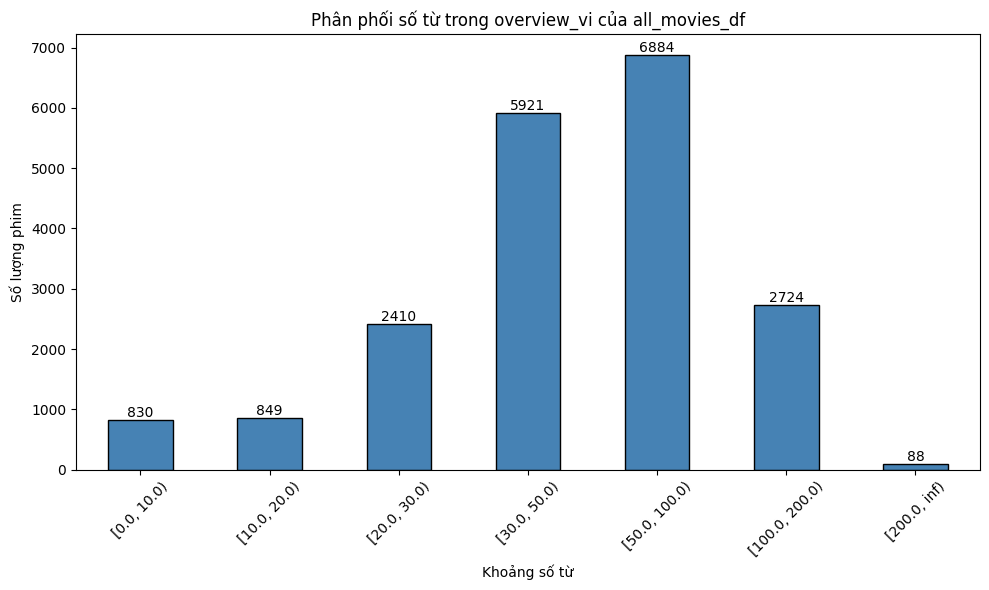

Hiển thị theo ngày release_date, từ cũ đến mới:


,tmdbId,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
12328,88953.0,Ucho,Chính phủ Lud trở thành nghi phạm sau khi nhiề...,"[{'id': 9648, 'name': 'Phim Bí Ẩn'}, {'id': 18...",1990-01-01,/9cQyM8b7WpXU894VP3iJrnVDR27.jpg,False,/bjuttI5ewihYXhODlYXv82iKU1A.jpg,NaN,0,...,"[{'english_name': 'Czech', 'iso_639_1': 'cs', ...",Released,NaN,Ucho,False,7.247,73,42176.0,True,61
12708,30647.0,12:01 PM,12 giờ sáng là một bộ phim ngắn năm 1990 của J...,"[{'id': 878, 'name': 'Phim Khoa Học Viễn Tưởng'}]",1990-01-01,/zT5R8VahhZlE1TDcwEtmvyr8c8K.jpg,False,/eWFz1KIhWk4TOC4BCBRrAHNnP1d.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,12:01 PM,False,6.968,47,128844.0,True,24
11132,25018.0,Leatherface: The Texas Chainsaw Massacre III,Hai sinh viên đại học lái xe đến bờ biển bị dụ...,"[{'id': 27, 'name': 'Phim Kinh Dị'}, {'id': 53...",1990-01-12,/4Vhv0vRqirhvbudRcNctFgxoFtI.jpg,False,/1XVfmGPQslh25GMJeaggGtYPc9E.jpg,"{'id': 111751, 'name': 'Loạt phim Tử Thần Vùng...",2000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Leatherface: The Texas Chainsaw Massacre III,False,5.425,667,2461.0,True,40
11974,11060.0,Internal Affairs,Anh ta và cộng sự của Amy Wallace sẽ sớm xem x...,"[{'id': 80, 'name': 'Phim Hình Sự'}, {'id': 18...",1990-01-12,/A4pH8DiNFEf2AgXkM4zk3ZpblV.jpg,False,/a7RMVypNmxvEG0SzG9kXBJivfxX.jpg,NaN,15000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Internal Affairs,False,6.371,463,7791.0,True,27
12082,60778.0,Downtown,Sĩ quan Alex Kearney tuần tra một khu phố lớn ...,"[{'id': 28, 'name': 'Phim Hành Động'}, {'id': ...",1990-01-12,/mNZxZ9VcpNBTipjaKyZqEvvsKjB.jpg,False,/n23dBKQHqy7dlWVhW4Oc96xaGNa.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Downtown,False,5.696,46,26682.0,True,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12474,81895.0,MacGyver: Lost Treasure of Atlantis,Ông MacGyver và cụ của ông cuối cùng đã tìm ki...,"[{'id': 28, 'name': 'Phim Hành Động'}, {'id': ...",1994-05-14,/hcmocdC6Rp0w6C8M4i1yvewmgNL.jpg,False,/fjrLJZ18NfSPkByHeiGUqKw1TP1.jpg,"{'id': 209739, 'name': 'MacGyver Collection', ...",0,...,"[{'english_name': 'French', 'iso_639_1': 'fr',...",Released,NaN,MacGyver: Lost Treasure of Atlantis,False,6.300,64,73499.0,True,15
12065,124029.0,A Million to Juan,"Một ngày nọ, một ngày nọ, một người đàn ông cũ...","[{'id': 35, 'name': 'Phim Hài'}]",1994-05-15,/nA8ehfPUxzD6N7YgoWfR1PSYVlF.jpg,False,NaN,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,A Million to Juan,False,5.375,8,8843.0,True,63
12165,19223.0,Una pura formalità,Thanh tra đang nghi ngờ khi Onoff được đưa vào...,"[{'id': 9648, 'name': 'Phim Bí Ẩn'}, {'id': 53...",1994-05-15,/lDc5hmjfB5u4lHgo3rS4rKNYW54.jpg,False,/88FnsK3iF9rWdR36N3anp1oYVYJ.jpg,NaN,0,...,"[{'english_name': 'French', 'iso_639_1': 'fr',...",Released,NaN,Una pura formalità,False,7.403,402,26875.0,True,53
10559,64567.0,Grosse Fatigue,"Sự căng thẳng và quá mệt mỏi, ngôi sao điện ản...","[{'id': 35, 'name': 'Phim Hài'}]",1994-05-18,/aTe0UsF2dFW1TzpPI2R10ViW8m2.jpg,False,/4DgcfG8h13gGZQyUW7I4rWiU32I.jpg,NaN,0,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Grosse Fatigue,False,6.000,125,1174.0,True,75


Hiển thị theo số từ trong overview_vi, từ ít đến nhiều:


,tmdbId,title_vi,overview_vi,genres,release_date,poster_path,adult,backdrop_path,belongs_to_collection,budget,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,is_ai_translated,overview_vi_word_count
19699,1769437.0,Crisálida,,[],2026-09-03,/JqVOJ60AL9JzPQI6rbkcY9gv1b.jpg,False,/6V7GYUJPSJ0HmYhICiPR3bKsVaH.jpg,NaN,0,...,"[{'english_name': 'Portuguese', 'iso_639_1': '...",Released,NaN,Crisálida,False,0.000,0,NaN,True,0
19576,1767161.0,Μούσκεμα,,"[{'id': 16, 'name': 'Phim Hoạt Hình'}, {'id': ...",2026-09-06,/f8jX24mqvVc7J6PeUsfusu8D9mx.jpg,False,/q032qBCbP0UvqYNZHmE7ZiZXqp5.jpg,NaN,0,...,[],Released,NaN,Μούσκεμα,False,0.000,0,NaN,True,0
19568,1766996.0,Cinema Rialto,,"[{'id': 16, 'name': 'Phim Hoạt Hình'}, {'id': ...",2026-09-06,/alDgnmDcL97TNdbo3bMuFno4CEj.jpg,False,/o9VR7jxPZf1fqtiX6y2BTfj1hih.jpg,NaN,0,...,[],Released,NaN,Cinema Rialto,False,0.000,0,NaN,True,0
17920,1757657.0,덕창,,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2026-09-04,NaN,False,NaN,NaN,0,...,[],Released,NaN,덕창,False,0.000,0,NaN,True,0
17927,1755122.0,N E U R I L L A N,,[],2026-08-19,/1qytrTnwzAI0hXCPya6AcSXEQWJ.jpg,False,/oP6v3Up1o6xvfN1CLO74ltvWSRY.jpg,NaN,0,...,[],Released,NaN,N E U R I L L A N,False,0.000,0,NaN,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19193,1711881.0,Mamma Mia: Que inesperado!,♪ Hai người bên nhau gặp nhau và ♪ Một cuộc hẹ...,"[{'id': 99, 'name': 'Phim Tài Liệu'}]",2026-08-07,/h3t3zBbwYpMmIVR8PhAOFu2Kai0.jpg,False,/6dzBN3m4B3UJAPxs7mhWV3D2XX4.jpg,NaN,0,...,"[{'english_name': 'Spanish', 'iso_639_1': 'es'...",Released,NaN,Mamma Mia: Que inesperado!,False,0.000,0,NaN,True,15
1109,55015.0,Home Room,Một tay súng trường trung học có mặt ở trường ...,"[{'id': 18, 'name': 'Phim Chính Kịch'}]",2002-04-12,/37BPWVtB956pkDIZarmjR2GjKVs.jpg,False,/4cRIz8wkaH9BekOnRC9d8ki4xxV.jpg,NaN,0,...,"[{'english_name': 'Spanish', 'iso_639_1': 'es'...",Released,NaN,Home Room,False,6.800,42,6704.0,True,13
13636,353069.0,Ngày Của Mẹ,3 thế hệ tụ họp lại với nhau trong tuần trước ...,"[{'id': 35, 'name': 'Phim Hài'}, {'id': 18, 'n...",2016-04-28,/1TGkhTsbkm2v1nMGJW0eTOFBjAd.jpg,False,/3wRjFLgFbMcA05oIRD3jL58pBCm.jpg,NaN,25000000,...,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,NaN,Ngày Của Mẹ,False,6.000,1323,157667.0,True,14
6631,143800.0,Pokłosie,Hai anh em đang cố gắng tìm ra sự thật từ nhiề...,"[{'id': 9648, 'name': 'Phim Bí Ẩn'}, {'id': 18...",2012-11-09,/nOvZaOA5d0rDx7hg3XaC2TLNeAF.jpg,False,/jmlATmv6IEIDfrX9vrxoT3epLa9.jpg,NaN,0,...,"[{'english_name': 'Polish', 'iso_639_1': 'pl',...",Released,NaN,Pokłosie,False,6.600,100,98485.0,True,14


In [ ]:
all_movies_df = pd.concat([tmdb_df, latest_movies_df], ignore_index=True)

# Loại trùng
all_movies_df = all_movies_df.drop_duplicates(subset=['id'], keep='first')

# Số phim không có movieId là latest_movies_df
print("Số phim không có movieId là latest_movies_df: ", all_movies_df[all_movies_df['movieId'].isnull()].shape[0])

print("Thông tin cơ bản về all_movies_df:")
display(all_movies_df.count())
display(all_movies_df.info())
display(all_movies_df.head(5))

print("Phân phối số từ trong overview_vi của all_movies_df:")
plot_count_by_range(
    all_movies_df,
    bins=[0, 10, 20, 30, 50, 100, 200, float("inf")],
    title="Phân phối số từ trong overview_vi của all_movies_df",
)

# Luu all_movies_df ra file CSV
all_movies_df.to_csv(TMDB_DIR / 'all_movies_fully_translated.csv', index=False, encoding='utf-8-sig')

# Hiển thị theo ngày release_date, từ cũ đến mới
print("Hiển thị theo ngày release_date, từ cũ đến mới:")
display(all_movies_df.sort_values('release_date', ascending=True).head(1000))

# Hiển thị theo số từ trong overview_vi, từ ít đến nhiều
print("Hiển thị theo số từ trong overview_vi, từ ít đến nhiều:")
display(all_movies_df.sort_values('overview_vi', key=lambda x: x.str.len()).head(1000))

